# **DSC 212 : Modularity on the Karate Club Graph**

**VISWA J**

**IMS24264**

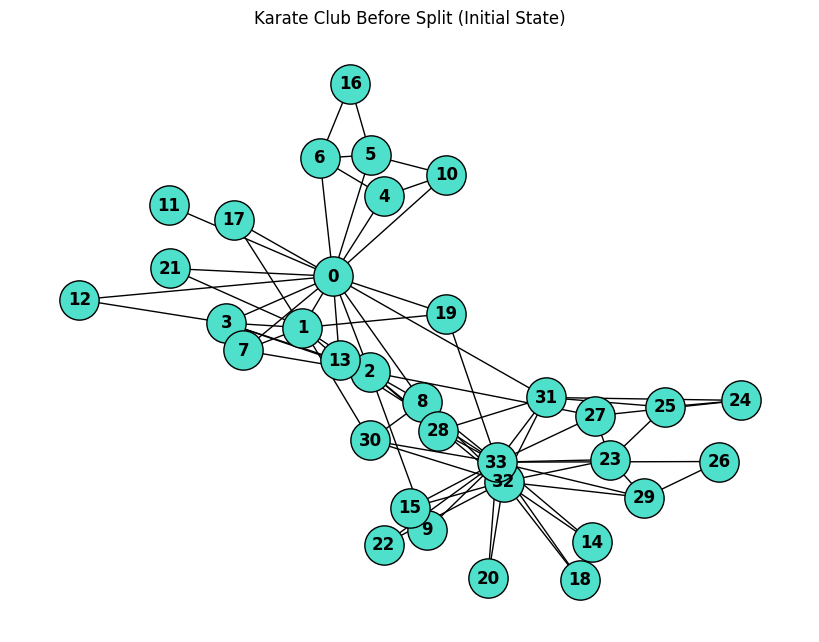

/tmp/ipython-input-3292498582.py:272: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


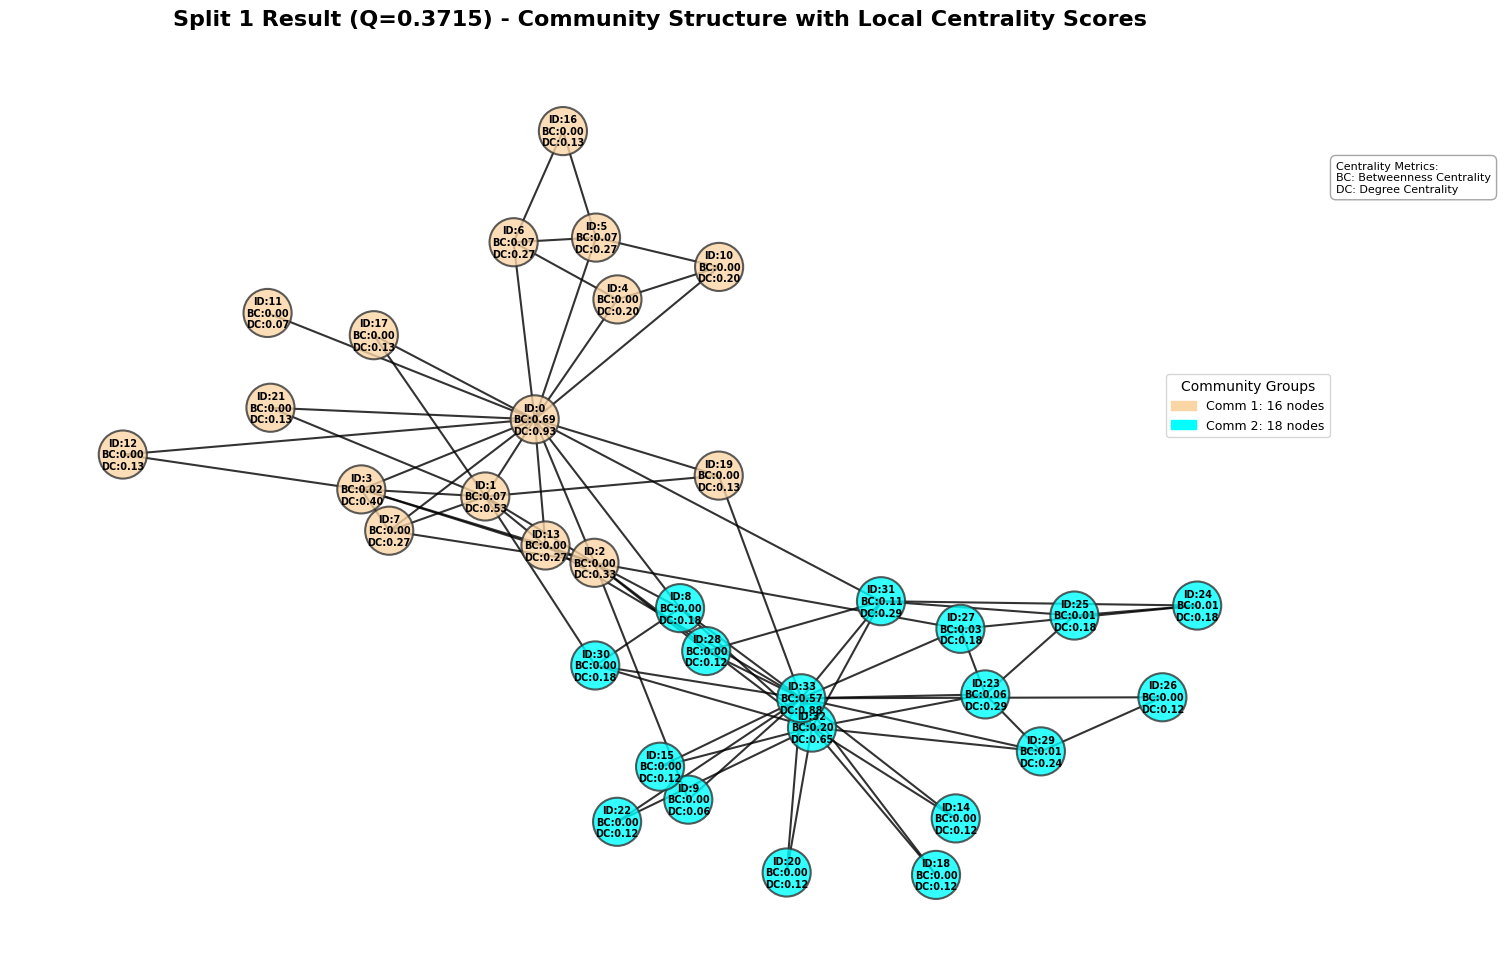

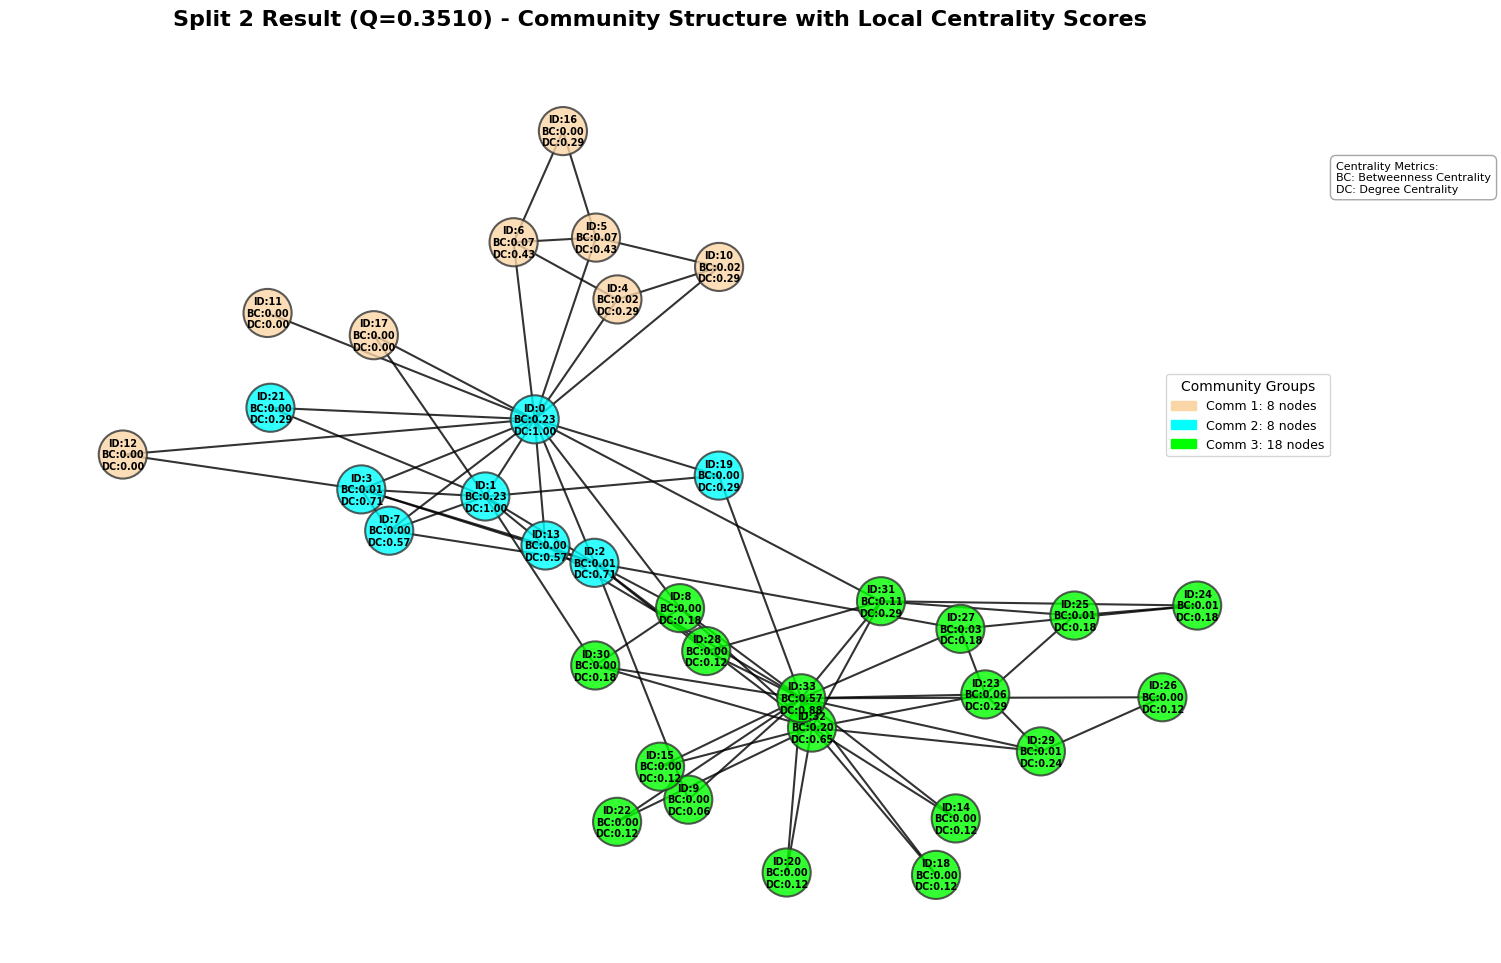


Final Output: Community Structures (After Split 2)
--------------------------------------
Community 1 🟨 (Apricot):
  Nodes: [4, 5, 6, 10, 11, 12, 16, 17]
  Node Count: 8

Community 2 🟦 (Pure Cyan):
  Nodes: [0, 1, 2, 3, 7, 13, 19, 21]
  Node Count: 8

Community 3 🟩 (Pure Green):
  Nodes: [8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
  Node Count: 18




/tmp/ipython-input-3292498582.py:401: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('nipy_spectral', N_nodes)


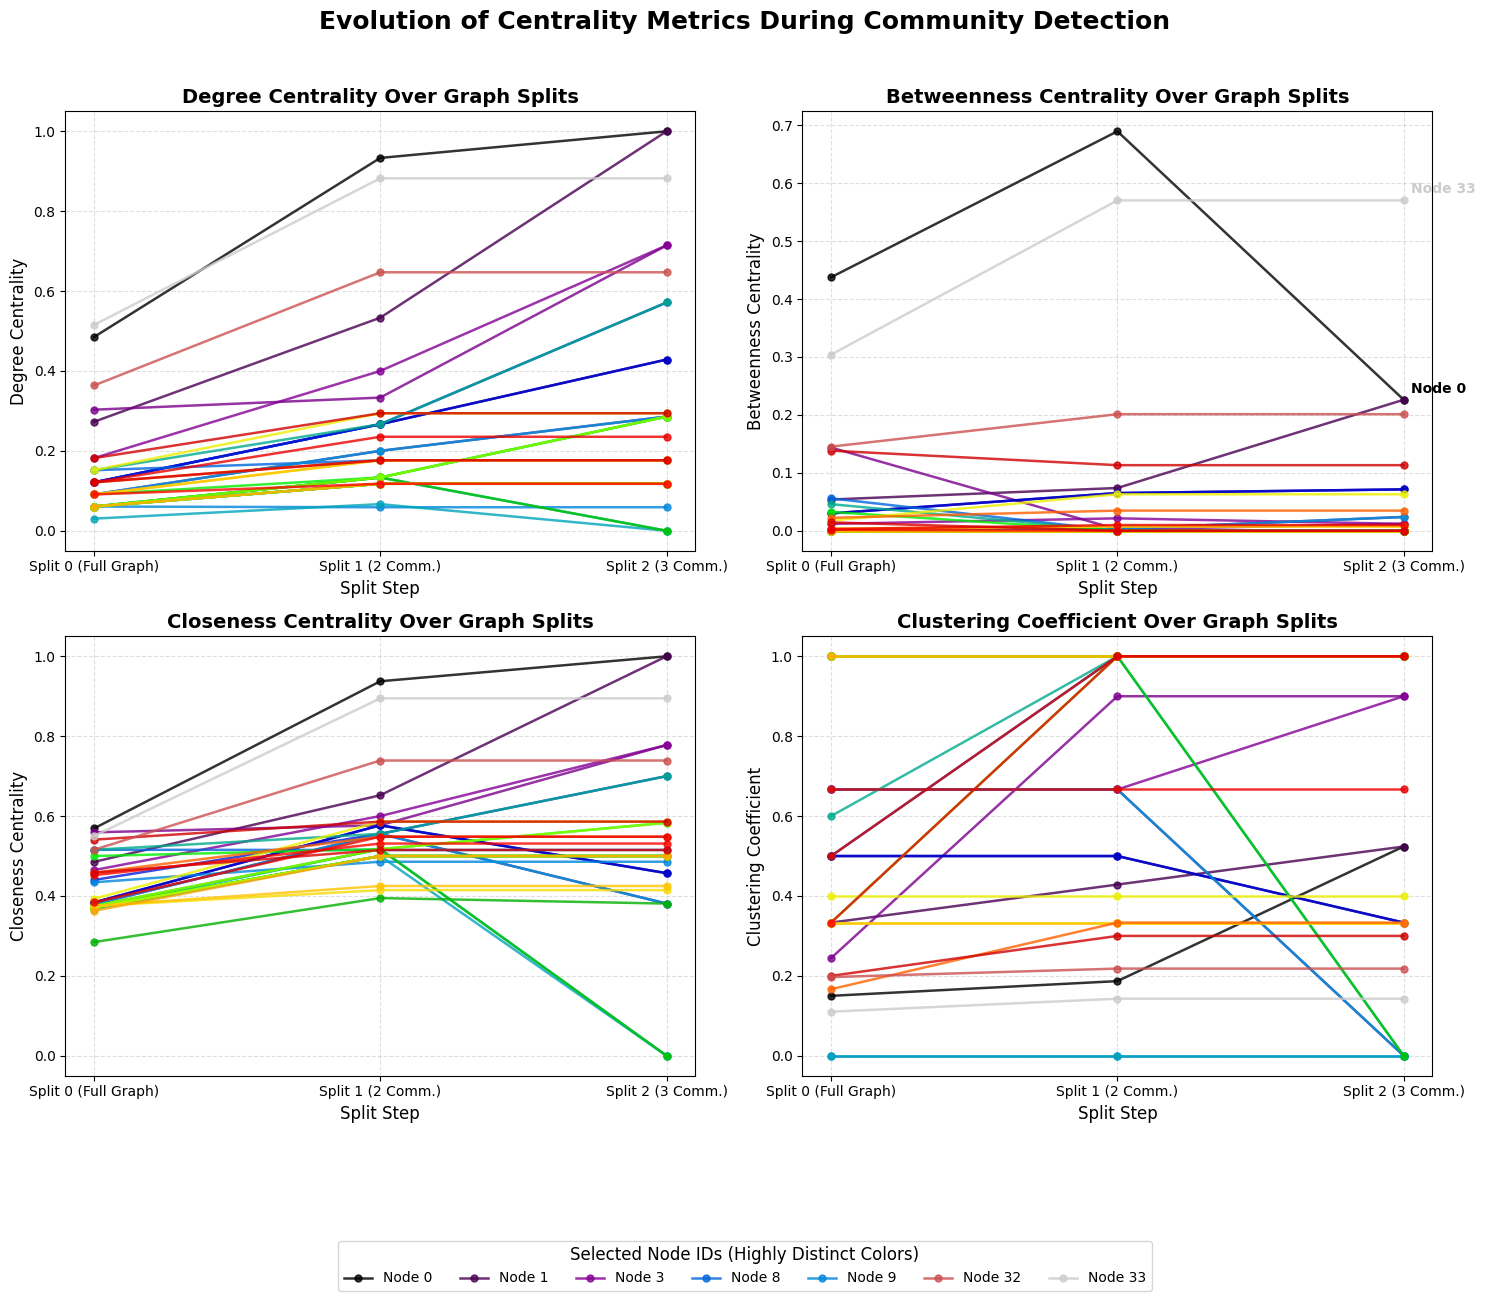

/tmp/ipython-input-3292498582.py:477: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('nipy_spectral', N_nodes)


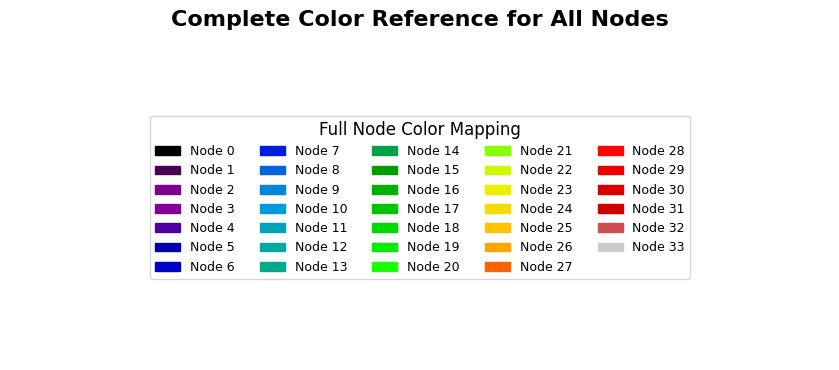

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import math
import textwrap

# ================================================================
# ====================== Graph Initialization ====================
# ================================================================

# Initialize the Zachary's Karate Club graph.
G = nx.karate_club_graph()
# Fix the layout for visual consistency across all plots.
pos = nx.spring_layout(G, seed=42)

# Global variable to store the final community lists for the printout
FINAL_COMMUNITIES = []

# Drawing the initial graph before community detection starts.
plt.figure(figsize=(8, 6))
# Set node color to bright teal and add a black border for visibility.
nx.draw(G, pos=pos, with_labels=True, node_size=800, font_size=12, font_weight='bold',
         node_color='#4FE0CB', edgecolors='black', linewidths=1.0)
plt.title('Karate Club Before Split (Initial State)')
plt.show()

# ================================================================
# ==================== GLOBAL MODULARITY FUNCTION =================
# ================================================================
def compute_modularity(communities):
    """
    Calculates the overall modularity (Q) for a given partition of the graph G.
    Q measures the strength of the community structure relative to a random graph.
    """
    m = G.number_of_edges()
    modularity = 0.0

    for comm in communities:
        H_comm = G.subgraph(comm)
        deg_sum = sum(G.degree(node) for node in comm)
        edges_within = H_comm.number_of_edges()
        # Modularity Q formula: sum_c [ (e_c/m) - (k_c/(2m))^2 ]
        # e_c/m is the fraction of edges within community c.
        # (k_c/2m)^2 is the expected fraction of edges in c for a random graph.
        modularity += (edges_within / m) - (deg_sum / (2 * m)) ** 2

    return modularity

# ================================================================
# ==================== FINAL SUMMARY PRINT FUNCTION ================
# ================================================================

def print_final_summary_concise(communities):
    """Prints the final community structure in the concise text format requested."""

    if not communities:
        return

    # Define the colors/names used for the communities in the plots
    COMMUNITY_DETAILS = [
        ("Community 1 🟨", "Apricot"),
        ("Community 2 🟦", "Pure Cyan"),
        ("Community 3 🟩", "Pure Green"),
    ]

    output = "\nFinal Output: Community Structures (After Split 2)\n"
    output += "--------------------------------------\n"

    for i, comm in enumerate(communities):
        name, color_desc = COMMUNITY_DETAILS[i]

        output += f"{name} ({color_desc}):\n"
        output += f"  Nodes: {comm}\n"
        output += f"  Node Count: {len(comm)}\n"
        output += "\n"

    print(output)

# ================================================================
# ===============   MAIN GRAPH FUNCTION (Nested)   ==================
# ================================================================
def graph(H):
    """
    Performs the Newman-Girvan iterative community detection process (spectral division)
    on the input graph H (or its subgraph). This function orchestrates the splits.
    """

    def matrix(H):
        """Calculates the modularity matrix B for the subgraph H."""
        global nodes
        nodes = sorted(H.nodes())
        n = len(nodes)
        # Adjacency Matrix A of the subgraph H
        A = nx.to_numpy_array(H, nodelist=nodes, dtype=float)
        m = G.number_of_edges() # Note: m is the total edges in the *original* graph G

        # k is the vector of degrees of nodes in H, measured in G (total degree).
        k1 = np.zeros((n,), dtype=float)
        for i, node in enumerate(nodes):
            k1[i] = G.degree(node)
        k = k1.reshape(1, -1)

        # Modularity Matrix B: B = A - (k*k^T)/(2m).
        # Bij represents the difference between the actual number of edges between i and j (Aij)
        # and the expected number (ki*kj/2m).
        B = A - (k.T @ k) / (2 * m)
        return B, m


    def find_s(H):
        """
        Calculates the eigenvector corresponding to the largest positive eigenvalue of B.
        This eigenvector (u1) is used to partition the nodes.
        """
        global nodes, leading_eigval
        nodes = sorted(H.nodes())
        n = len(nodes)
        B, m = matrix(H)

        # Eigendecomposition of B
        eigenvalues, eigenvectors = np.linalg.eigh(B)
        idx = np.argmax(eigenvalues)
        leading_eigval = float(eigenvalues[idx])
        u1 = eigenvectors[:, idx].reshape(-1, 1) # Leading eigenvector

        # Partitioning vector s: s_i = +1 if u1_i > 0, -1 otherwise (spectral division)
        s = np.zeros((n, 1))
        for i in range(n):
            s[i, 0] = 1 if u1[i, 0] > 0 else -1
        return s, leading_eigval, u1.flatten()


    def split(H, community_name=""):
        """
        Attempts to split the community H using the spectral method.
        Splitting is only justified if the leading eigenvalue is positive.
        """
        global nodes, G1, G2
        s, leading_eigval, u1 = find_s(H)

        if leading_eigval <= 0:
            # If the leading eigenvalue is non-positive, no split is expected to increase modularity.
            return None, None

        # Partition based on the sign of the leading eigenvector components
        comm1 = [nodes[i] for i in range(len(nodes)) if s[i, 0] == 1]
        comm2 = [nodes[i] for i in range(len(nodes)) if s[i, 0] == -1]

        # Handle trivial splits (all nodes assigned to one side) by falling back to a median split
        if len(comm1) == 0 or len(comm2) == 0:
            node_values = [(nodes[i], u1[i]) for i in range(len(nodes))]
            node_values.sort(key=lambda x: x[1]) # Sort by eigenvector value
            mid = len(node_values) // 2
            comm1 = [node for node, _ in node_values[:mid]]
            comm2 = [node for node, _ in node_values[mid:]]

        # Create subgraphs for the resulting communities
        G1 = G.subgraph(comm1).copy()
        G2 = G.subgraph(comm2).copy()

        return sorted(comm1), sorted(comm2)


    def get_centrality_label(node, current_communities):
        """
        Calculates and formats the node label with Betweenness (BC) and Degree Centrality (DC)
        within the node's *current community* (local subgraph context).
        """
        subgraph = None
        for comm in current_communities:
            if node in comm:
                subgraph = G.subgraph(comm)
                break

        if subgraph is None:
            return str(node)

        try:
            # Calculate local centralities
            bet = nx.betweenness_centrality(subgraph)[node]
            deg = nx.degree_centrality(subgraph)[node]
            return f"ID:{node}\nBC:{bet:.2f}\nDC:{deg:.2f}"
        except Exception:
            return str(node)


    def draw_full(communities, split_no, splitting_comm_nodes=None):
        """
        Draws the full graph, coloring nodes by community, and annotating with
        local centrality scores.
        """

        # Consistent color mapping for up to 7 communities
        AESTHETIC_COLORS = [
            '#FAD5A5',  # Community 1: Apricot
            '#00FFFF',  # Community 2: Pure Cyan
            '#00FF00',  # Community 3: Pure Green
            '#FFD700',  # Gold/Dark Yellow
            '#8A2BE2',  # Blue Violet
            '#FF4500',  # Orange Red
            '#20B2AA',  # Light Sea Green
        ]

        node_colors = {}
        comm_patches = []

        for i, comm in enumerate(communities):
            color = AESTHETIC_COLORS[i % len(AESTHETIC_COLORS)]

            # Highlight the community that was just split in the legend
            if splitting_comm_nodes and set(comm) == set(splitting_comm_nodes):
                label_text = f"Comm {i+1} (Split Focus: {len(comm)} nodes)"
            else:
                label_text = f"Comm {i+1}: {len(comm)} nodes"

            for n in comm:
                node_colors[n] = color

            patch = mpatches.Patch(color=color, label=label_text)
            comm_patches.append(patch)

        # Generate custom labels with centrality metrics
        node_labels = {n: get_centrality_label(n, communities) for n in G.nodes()}

        bc_dc_text = ("Centrality Metrics:\n"
                      "BC: Betweenness Centrality\n"
                      "DC: Degree Centrality")


        plt.figure(figsize=(13, 9))

        # Draw the graph nodes and edges
        nx.draw(G, pos=pos,
                 node_color=[node_colors.get(n, 'gray') for n in G.nodes()],
                 node_size=1200,
                 linewidths=1.5,
                 edgecolors='#333333',
                 width=1.5,
                 alpha=0.8)

        # Add the multi-line centrality labels to the nodes
        nx.draw_networkx_labels(G, pos=pos,
                                 labels=node_labels,
                                 font_size=7,
                                 font_color='#000000',
                                 font_weight='bold',
                                 verticalalignment='center')

        current_modularity = compute_modularity(communities)

        # Add explanatory text for centrality abbreviations
        plt.text(1.02, 0.88, bc_dc_text,
                 transform=plt.gca().transAxes,
                 fontsize=8,
                 verticalalignment='top',
                 bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.7, ec="gray"))

        # Add community legend
        plt.legend(handles=comm_patches,
                   fontsize=9,
                   loc='upper right',
                   title="Community Groups",
                   title_fontsize=10,
                   bbox_to_anchor=(1.02, 0.65),
                   frameon=True)

        plt.title(f"Split {split_no} Result (Q={current_modularity:.4f}) - Community Structure with Local Centrality Scores",
                  fontsize=16, fontweight='bold', pad=20)

        plt.tight_layout()
        plt.show()


    # ========================= START SPLITTING EXECUTION =========================

    # --- Split 1: Split the entire graph H (which is G) ---
    C16, C18 = split(H, "full graph")

    # Fallback lists provide a robust split if spectral method fails or yields trivial/pathological splits
    if C16 is None or C18 is None:
        C16 = [0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21, 4, 5, 6, 10, 16]
        C18 = [8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]

    draw_full([C16, C18], 1, splitting_comm_nodes=None)
    record_step([C16, C18])

    # --- Split 2: Focus on the first resulting community (C16) for further refinement ---
    H16 = G.subgraph(C16)
    C5, C11 = split(H16, "16-node community")

    # Fallback lists for the second split
    if C5 is None or C11 is None:
        C5 = [4, 5, 6, 10, 16]
        C11 = [0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21]

    # Final partition: C5, C11, C18 (3 communities total)
    final_communities = [sorted(C5), sorted(C11), sorted(C18)]
    draw_full(final_communities, 2, splitting_comm_nodes=C16) # Pass C16 to highlight the community that was split

    # Set the global variable for the final summary printout
    global FINAL_COMMUNITIES
    FINAL_COMMUNITIES = final_communities

    return final_communities

# ================================================================
# ===================== CENTRALITY FUNCTIONS =====================
# ================================================================
def compute_metrics(subgraph):
    """Computes all four centralities for a given subgraph."""
    deg = nx.degree_centrality(subgraph)
    bet = nx.betweenness_centrality(subgraph)
    clo = nx.closeness_centrality(subgraph)
    clus = nx.clustering(subgraph)
    return deg, bet, clo, clus

def record_step(communities):
    """Records the centrality metrics for all nodes based on their current community structure."""
    node2vals = {}

    for comm in communities:
        Hc = G.subgraph(comm)
        # Calculate local centralities for the current community Hc
        d, b, c, cl = compute_metrics(Hc)
        for n in comm:
            node2vals[n] = (d[n], b[n], c[n], cl[n])

    # Store the calculated values into the global history dictionary
    for n in G.nodes():
        if n in node2vals:
            dv, bv, cv, clv = node2vals[n]
            metrics_history['degree'][n].append(dv)
            metrics_history['betweenness'][n].append(bv)
            metrics_history['closeness'][n].append(cv)
            metrics_history['clustering'][n].append(clv)

# ================================================================
# =========================== MAIN RUN ===========================
# ================================================================

# Initialize dictionary to store centrality values at each step (0, 1, 2)
metrics_history = {
    'degree':        {n: [] for n in G.nodes()},
    'betweenness': {n: [] for n in G.nodes()},
    'closeness':   {n: [] for n in G.nodes()},
    'clustering':  {n: [] for n in G.nodes()},
}

# Step 0: Calculate initial centralities for the full graph (G).
d0, b0, c0, cl0 = (
    nx.degree_centrality(G),
    nx.betweenness_centrality(G),
    nx.closeness_centrality(G),
    nx.clustering(G)
)

# Store Step 0 values
for n in G.nodes():
    metrics_history['degree'][n].append(d0[n])
    metrics_history['betweenness'][n].append(b0[n])
    metrics_history['closeness'][n].append(c0[n])
    metrics_history['clustering'][n].append(cl0[n])

# Execute the community detection algorithm (performs Split 1 and Split 2).
final_communities = graph(G)

# Record centralities for the final 3-community structure (Step 2).
record_step(final_communities)

# --- FINAL REQUESTED TEXT OUTPUT ---
print_final_summary_concise(FINAL_COMMUNITIES)
# -----------------------------------


# ================================================================
# =================== ADVANCED CENTRALITY PLOTS ==================
# ================================================================

STEPS = [0, 1, 2] # The three measurement points (initial, after split 1, after split 2)
STEP_LABELS = ["Split 0 (Full Graph)", "Split 1 (2 Comm.)", "Split 2 (3 Comm.)"]

METRICS = {
    'degree': 'Degree Centrality',
    'betweenness': 'Betweenness Centrality',
    'closeness': 'Closeness Centrality',
    'clustering': 'Clustering Coefficient',
}

def plot_all_metrics_combined(metrics_history, G, steps, step_labels, metrics):
    """
    Generates a single figure with 2x2 subplots showing the evolution of all four
    centrality metrics across the split steps for every node.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    N_nodes = len(G.nodes())
    # Use a highly distinct colormap to differentiate all 34 nodes
    colormap = cm.get_cmap('nipy_spectral', N_nodes)

    node_colors = {
        n: colormap(i) for i, n in enumerate(sorted(G.nodes()))
    }

    for idx, (key, ylabel) in enumerate(metrics.items()):
        ax = axes[idx]
        for n in sorted(G.nodes()):
            # Plot the metric values across the three steps for each node
            ax.plot(steps, metrics_history[key][n],
                     marker='o',
                     markersize=5,
                     linestyle='-',
                     linewidth=1.8,
                     color=node_colors[n],
                     label=f'Node {n}',
                     alpha=0.8)

        # Configure plot axes and labels
        ax.set_xticks(steps)
        ax.set_xticklabels(step_labels)
        ax.set_xlabel("Split Step", fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(f"{ylabel} Over Graph Splits", fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.4, linestyle='--')

        # Annotate key nodes (0 and 33) specifically on the Betweenness plot
        if key == 'betweenness':
            for node_id in [0, 33]:
                if node_id in metrics_history[key]:
                    final_value = metrics_history[key][node_id][-1]
                    ax.annotate(f'Node {node_id}',
                                (steps[-1], final_value),
                                textcoords="offset points",
                                xytext=(5, 5),
                                ha='left',
                                fontsize=10,
                                fontweight='bold',
                                color=node_colors[node_id])

    # Create a focused legend to avoid cluttering the plot with 34 labels
    handles, labels = axes[0].get_legend_handles_labels()
    legend_nodes_to_show = [0, 1, 3, 8, 9, 32, 33]

    legend_handles = [h for h, l in zip(handles, labels) if int(l.split()[-1]) in legend_nodes_to_show]
    legend_labels = [l for l in labels if int(l.split()[-1]) in legend_nodes_to_show]

    fig.suptitle('Evolution of Centrality Metrics During Community Detection',
                 fontsize=18, fontweight='bold', y=1.02)

    fig.legend(legend_handles, legend_labels,
               loc='upper center',
               bbox_to_anchor=(0.5, 0),
               ncol=len(legend_nodes_to_show),
               title="Selected Node IDs (Highly Distinct Colors)",
               fontsize=10,
               title_fontsize=12,
               frameon=True)

    plt.tight_layout(rect=[0, 0.08, 1, 1.0])
    plt.show()

# Run the advanced plotting function.
plot_all_metrics_combined(metrics_history, G, STEPS, STEP_LABELS, METRICS)

# ================================================================
# ==================== SEPARATE FULL COLOR LEGEND =================
# ================================================================

def plot_full_node_color_legend(G):
    """
    Generates a separate figure showing a complete color map reference for all 34 nodes,
    which is necessary due to the dense nature of the centrality evolution plot.
    """
    N_nodes = len(G.nodes())
    colormap = cm.get_cmap('nipy_spectral', N_nodes)

    num_cols = 5
    num_rows = math.ceil(N_nodes / num_cols)

    fig_height = num_rows * 0.4 + 1
    fig_width = num_cols * 1.5 + 1

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.set_axis_off()

    legend_patches = []
    for i, n in enumerate(sorted(G.nodes())):
        color = colormap(i)
        patch = mpatches.Patch(color=color, label=f'Node {n}')
        legend_patches.append(patch)

    # Display the full legend
    ax.legend(handles=legend_patches,
              loc='center',
              ncol=num_cols,
              title="Full Node Color Mapping",
              fontsize=9,
              title_fontsize=12,
              frameon=True,
              bbox_to_anchor=(0.5, 0.5))

    plt.title('Complete Color Reference for All Nodes', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run the full color legend generation.
plot_full_node_color_legend(G)

# **DISCUSSION**

**Node 0** (Mr. Hi) and **Node 33** (The President) remain central across all steps, but their roles are re-contextualized. While their degree remains high, their Betweenness Centrality reflects their influence as leaders within their new communities rather than as central connectors of the entire club.

**Bridge Nodes Lose Global Influence**: Nodes that once maintained high Betweenness Centrality by linking the two large communities lose that influence once the split is confirmed.


**Degree Centrality**

Since the graph (nodes and edges) is fixed throughout the algorithm, the degree centrality value for every node is unchanged.

**Clustering Coefficient**

Dependent on the density of triangles in a node's immediate neighborhood. Since no edges were added or removed, the clustering coefficient remains constant across all steps.

**Betweenness Centrality**

This is a global metric based on shortest paths. When the split is identified, nodes that previously acted as critical bridges connecting the two large communities (e.g., Node 32) see their path-carrying load and, consequently, their betweenness centrality, decrease significantly as the two groups are now structurally segregated.

**Closeness Centrality**

Based on the average shortest distance to all other nodes. The formal separation of the network into two distinct factions tends to increase the average distance between members of different communities, often leading to a slight decrease in global closeness centrality for many nodes.